<a href="https://colab.research.google.com/github/melon095/IS_211_MANDATORY_ASSIGNMENT/blob/main/Pharmacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from dataclasses import dataclass, field
from enum import Enum
import random
from typing import List


class PrescriptionLevel(Enum):
    LOW = 1
    MEDIUM = 2
    HIGH = 3


@dataclass
class Person:
    name: str
    wanted_prescriptions: list[str]
    received_prescriptions: list[str] = field(default_factory=list)


ASPIRIN = "Aspirin"
LISINOPRIL = "Lisinopril"
METFORMIN = "Metformin"
MORPHINE = "Morphine"
IBUPROFEN = "Ibuprofen"
ANTIBIOTIC = "Antibiotic"

DROGAS = [ASPIRIN, LISINOPRIL, METFORMIN, MORPHINE, IBUPROFEN, ANTIBIOTIC]


@dataclass
class Prescription:
    name: str
    level: PrescriptionLevel
    person_name: str = ""


def prescription_queue_algorithm() -> tuple[List[Prescription], List[Person]]:
    queues = {
        PrescriptionLevel.HIGH: [],
        PrescriptionLevel.MEDIUM: [],
        PrescriptionLevel.LOW: [],
    }

    people = [
        Person(
            name=f"Person_{i}",
            wanted_prescriptions=[
                drug for drug in DROGAS if random.random() > 0.5
            ],
        )
        for i in range(100)
    ]

    prescription_mapping = {
        ASPIRIN: PrescriptionLevel.LOW,
        IBUPROFEN: PrescriptionLevel.LOW,
        LISINOPRIL: PrescriptionLevel.MEDIUM,
        METFORMIN: PrescriptionLevel.MEDIUM,
        MORPHINE: PrescriptionLevel.HIGH,
        ANTIBIOTIC: PrescriptionLevel.HIGH,
    }

    for person in people:
        for prescription_name in person.wanted_prescriptions:
            level = prescription_mapping[prescription_name]
            queues[level].append(
                Prescription(prescription_name, level, person.name)
            )
            person.received_prescriptions.append(prescription_name)

    filtered = []

    for level in [
        PrescriptionLevel.HIGH,
        PrescriptionLevel.MEDIUM,
        PrescriptionLevel.LOW,
    ]:
        for prescription in queues[level]:
            filtered.append(prescription)

    return filtered, people


def drug_inventory_algorithm():
    class Batch:
        def __init__(self, batch_id: str, expiry_date: str, quantity: int):
            self.batch_id = batch_id
            self.expiry_date = expiry_date
            self.quantity = quantity
            self.next = None

    class DrugInventory:
        def __init__(self):
            self.inventory = {}

        def add_batch(
            self, drug_id: str, batch_id: str, expiry_date: str, quantity: int
        ):
            new_batch = Batch(batch_id, expiry_date, quantity)
            if drug_id not in self.inventory:
                self.inventory[drug_id] = new_batch
            else:
                current = self.inventory[drug_id]
                if new_batch.expiry_date < current.expiry_date:
                    new_batch.next = current
                    self.inventory[drug_id] = new_batch
                else:
                    while (
                        current.next
                        and current.next.expiry_date < new_batch.expiry_date
                    ):
                        current = current.next
                    new_batch.next = current.next
                    current.next = new_batch

        def dispense_drug(self, drug_id: str, quantity: int) -> bool:
            if drug_id not in self.inventory:
                return False

            current = self.inventory[drug_id]
            while current and quantity > 0:
                if current.quantity >= quantity:
                    current.quantity -= quantity
                    return True
                quantity -= current.quantity
                current = current.next

            return False

    drug_inventory = DrugInventory()
    drug_inventory.add_batch("Aspirin", "BATCH001", "2024-01-01", 100)
    drug_inventory.add_batch("Aspirin", "BATCH002", "2023-12-01", 50)
    drug_inventory.add_batch("Aspirin", "BATCH003", "2024-02-01", 75)
    drug_inventory.add_batch("Ibuprofen", "BATCH001", "2024-03-01", 200)
    drug_inventory.add_batch("Ibuprofen", "BATCH002", "2024-04-01", 150)
    drug_inventory.add_batch("Lisinopril", "BATCH001", "2024-05-01", 100)
    drug_inventory.add_batch("Metformin", "BATCH001", "2024-06-01", 120)

    if drug_inventory.dispense_drug("Aspirin", 30):
        print("Dispensed 30 Aspirin.")
    else:
        print("Failed to dispense Aspirin.")

    if drug_inventory.dispense_drug("Ibuprofen", 50):
        print("Dispensed 50 Ibuprofen.")
    else:
        print("Failed to dispense Ibuprofen.")

    def print_linked_lists(drug_inventory: DrugInventory):
        for drug_id, batch in drug_inventory.inventory.items():
            print(f"Drug: {drug_id}")
            current = batch
            while current:
                print(
                    f"  Batch ID: {current.batch_id}, Expiry Date: {current.expiry_date}, Quantity: {current.quantity}"
                )
                current = current.next

    print_linked_lists(drug_inventory)


if __name__ == "__main__":
    prescriptions, people = prescription_queue_algorithm()

    for person in people:
        if person.received_prescriptions:
            print(
                f"{person.name} received: {', '.join(person.received_prescriptions)}"
            )

    print("\nPrescription queue:")
    for p in prescriptions:
        print(f"{p.person_name} - {p.name} ({p.level.name})")

    print("\nDrug Inventory Algorithm:")
    drug_inventory_algorithm()


Person_0 received: Aspirin, Morphine, Ibuprofen, Antibiotic
Person_1 received: Aspirin, Ibuprofen
Person_2 received: Lisinopril, Metformin, Ibuprofen
Person_3 received: Metformin, Morphine, Antibiotic
Person_4 received: Aspirin, Lisinopril, Metformin, Morphine, Antibiotic
Person_5 received: Aspirin, Lisinopril, Morphine, Antibiotic
Person_6 received: Lisinopril, Ibuprofen
Person_7 received: Lisinopril, Morphine, Ibuprofen, Antibiotic
Person_8 received: Metformin, Morphine, Ibuprofen, Antibiotic
Person_9 received: Metformin, Morphine, Antibiotic
Person_10 received: Morphine, Ibuprofen
Person_11 received: Morphine, Ibuprofen, Antibiotic
Person_12 received: Lisinopril, Morphine, Ibuprofen
Person_13 received: Metformin, Morphine, Ibuprofen
Person_14 received: Lisinopril, Metformin, Morphine, Antibiotic
Person_15 received: Lisinopril, Metformin, Ibuprofen, Antibiotic
Person_16 received: Ibuprofen, Antibiotic
Person_17 received: Metformin, Morphine, Antibiotic
Person_18 received: Lisinopril,

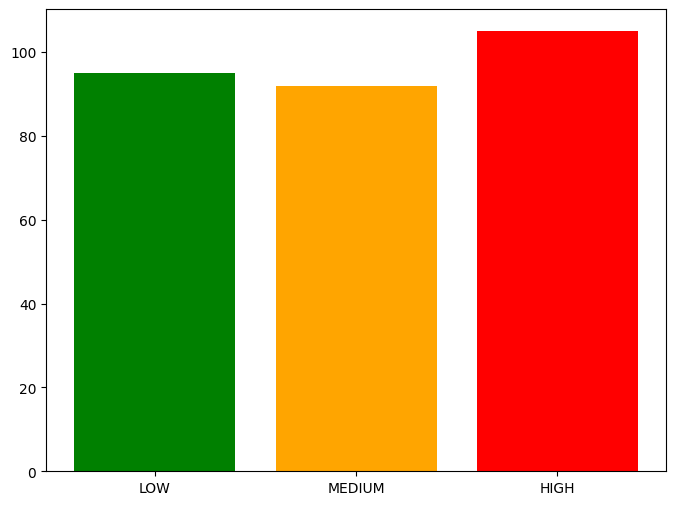

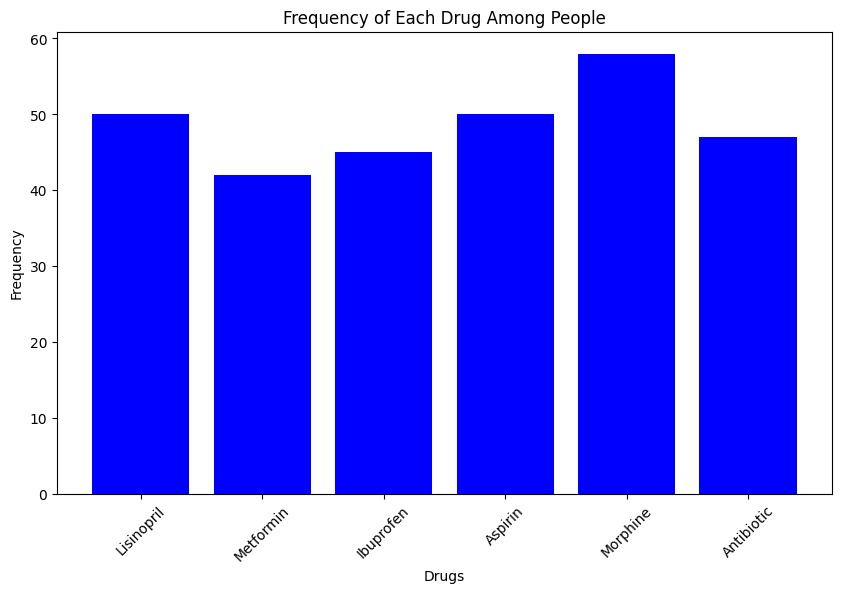

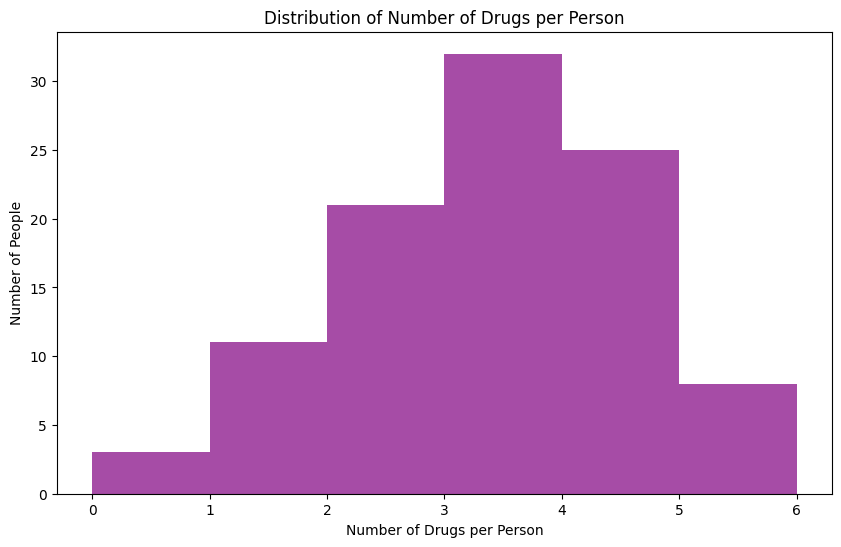

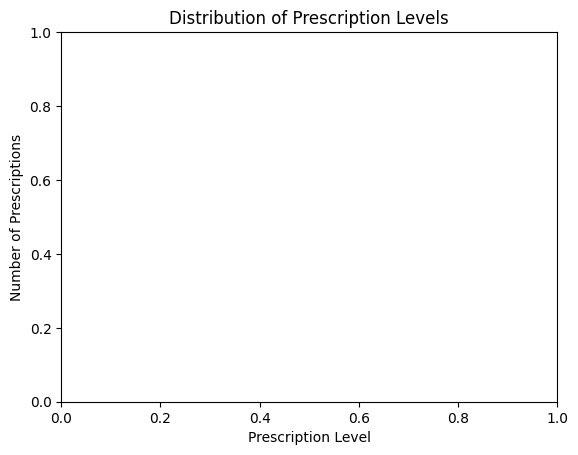

In [16]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
prescriptions, people = prescription_queue_algorithm()

levels = [p.level for p in prescriptions]
level_counts = Counter(levels)
level_names = [level.name for level in PrescriptionLevel]
counts = [level_counts[level] for level in PrescriptionLevel]

plt.figure(figsize=(8, 6))
plt.bar(level_names, counts, color=['green', 'orange', 'red'])

drug_counts = Counter(drug for person in people for drug in person.wanted_prescriptions)
drug_names = list(drug_counts.keys())
drug_frequencies = list(drug_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(drug_names, drug_frequencies, color='blue')
plt.xlabel('Drugs')
plt.ylabel('Frequency')
plt.title('Frequency of Each Drug Among People')
plt.xticks(rotation=45)
plt.show()

person_drug_counts = [len(person.wanted_prescriptions) for person in people]
plt.figure(figsize=(10, 6))
plt.hist(person_drug_counts, bins=range(max(person_drug_counts) + 1), color='purple', alpha=0.7)
plt.xlabel('Number of Drugs per Person')
plt.ylabel('Number of People')
plt.title('Distribution of Number of Drugs per Person')
plt.show()
plt.xlabel('Prescription Level')
plt.ylabel('Number of Prescriptions')
plt.title('Distribution of Prescription Levels')
plt.show()